# Strong Lens Transient Dataset


In [ ]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.PointSource.point_source import PointSource
from tqdm import tqdm

# Output directory for arrays and diagnostic figures.
output_dir = './data'
os.makedirs(output_dir, exist_ok=True)

# Flat ΛCDM cosmology (Planck 2018) used by LensCosmo for distance calculations.
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)



## Lens Configuration Setup


In [2]:
def generate_random_lens_config(num_samples=1000, img_size=240, pixel_scale=0.05):
    """Sample lensing configurations with a central halo and scattered satellites."""

    configs = []

    for _ in range(num_samples):
        num_lenses = 3
        satellite_count = num_lenses - 1
        config = {'num_lenses': num_lenses}

        # Draw source and lens redshifts, clipping to keep the lens in front of the source.
        z_source = np.random.uniform(1.0, 3.0)
        z_lens = np.clip(np.random.normal(0.4, 0.2), 0.1, z_source - 0.1)
        config['z_source'] = z_source
        config['z_lens'] = z_lens

        # Helper for converting halo velocity dispersion to angular Einstein radius.
        lens_cosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)

        lens_models, lens_params, lens_light_params = ['SIE'] * num_lenses, [], []

        # Sample halo masses and promote the most massive halo to the central position.
        sampled_masses = 10 ** np.random.uniform(12.0, 13.0, num_lenses)
        central_idx = int(np.argmax(sampled_masses))
        lens_masses = [float(sampled_masses[central_idx])] + [
            float(mass)
            for idx, mass in enumerate(sampled_masses)
            if idx != central_idx
        ]

        # Anchor the Einstein-scale geometry to the dominant (central) halo.
        central_mass = lens_masses[0]
        central_sigma_v = float(200.0 * (central_mass / 1e12) ** 0.25)
        theta_E_main = float(lens_cosmo.sis_sigma_v2theta_E(central_sigma_v))

        # Lens placement constraints.
        half_field = 0.5 * img_size * pixel_scale
        margin = 0.5  # arcsec
        if half_field <= margin:
            raise ValueError("Image stamp too small to accommodate the requested edge margin.")
        inner_radius = 0.3 * theta_E_main
        outer_radius_cap = half_field - margin
        outer_radius = min(1.5 * theta_E_main, outer_radius_cap)
        if outer_radius <= inner_radius:
            raise RuntimeError("Satellite radial range collapses under field-of-view constraints.")

        # Place the central halo near the origin within the allowed window.
        central_bounds = min(half_field - margin, 0.15)
        for _attempt in range(1000):
            central_x = np.random.uniform(-0.15, 0.15)
            central_y = np.random.uniform(-0.15, 0.15)
            if abs(central_x) <= central_bounds and abs(central_y) <= central_bounds:
                break
        else:
            raise RuntimeError("Unable to place the central lens within the required margin.")

        # Rejection sampling for satellite halos with packing and separation constraints.
        base_min_sep = max(0.25, 1.2 * pixel_scale)
        max_draws = 5000

        # Draw satellites until the packing and separation constraints are satisfied.
        def draw_satellites(min_sep_threshold):
            satellites, radii, draws = [], [], 0
            while draws < max_draws and len(satellites) < satellite_count:
                draws += 1
                radius = float(np.sqrt(np.random.uniform(inner_radius ** 2, outer_radius ** 2)))
                angle = np.random.uniform(0, 2 * np.pi)
                sat_x = central_x + radius * np.cos(angle)
                sat_y = central_y + radius * np.sin(angle)

                if abs(sat_x) > half_field - margin or abs(sat_y) > half_field - margin:
                    continue
                if np.hypot(sat_x - central_x, sat_y - central_y) < min_sep_threshold:
                    continue
                if any(np.hypot(sat_x - px, sat_y - py) < min_sep_threshold for px, py in satellites):
                    continue

                satellites.append((float(sat_x), float(sat_y)))
                radii.append(radius)

            return satellites, radii, draws

        satellites, radii, _ = draw_satellites(base_min_sep)
        min_sep_threshold = base_min_sep
        if len(satellites) < satellite_count:
            satellites, radii, _ = draw_satellites(0.8 * base_min_sep)
            min_sep_threshold = 0.8 * base_min_sep
            if len(satellites) < satellite_count:
                raise RuntimeError("Unable to place satellite lenses within the packing constraints.")

        positions = [(float(central_x), float(central_y))] + satellites

        # Check to ensure every halo remains inside the 0.5" edge margin.
        all_inside_margin = all(
            abs(x) <= half_field - margin and abs(y) <= half_field - margin
            for x, y in positions
        )
        if not all_inside_margin:
            raise RuntimeError("Lens placement produced coordinates outside the safe margin.")

        min_pairwise_sep = min(
            np.hypot(x1 - x2, y1 - y2)
            for idx1, (x1, y1) in enumerate(positions)
            for idx2, (x2, y2) in enumerate(positions)
            if idx2 > idx1
        )

        sorted_radii = sorted(radii)
        radii_log = ', '.join(f'{r:.3f}' for r in sorted_radii)
        print(
            f"Lens placement: central=({positions[0][0]:.3f}, {positions[0][1]:.3f}), "
            f"radii=[{radii_log}], "
            f"min_sep={min_pairwise_sep:.3f}"
        )

        config['placement_summary'] = {
            'central': positions[0],
            'satellite_radii': [float(r) for r in sorted_radii],
            'min_pairwise_sep': float(min_pairwise_sep),
            'min_sep_threshold': float(min_sep_threshold),
        }

        # Populate the lenstronomy kwargs for each halo at its sampled position.
        for mass, (center_x, center_y) in zip(lens_masses, positions):
            sigma_v = float(200.0 * (mass / 1e12) ** 0.25)
            theta_E = float(lens_cosmo.sis_sigma_v2theta_E(sigma_v))

            e1 = np.random.uniform(-0.2, 0.2)
            e2 = np.random.uniform(-0.2, 0.2)

            lens_params.append({
                'theta_E': theta_E,
                'e1': e1,
                'e2': e2,
                'center_x': center_x,
                'center_y': center_y,
            })

            sigma_ratio = sigma_v / 200.0
            lens_light_params.append({
                'amp': float(np.random.uniform(1.0, 2.5) * sigma_ratio ** 1.2),
                'R_sersic': float(np.clip(theta_E * np.random.uniform(0.35, 0.7), 0.15, 0.9)),
                'n_sersic': float(np.clip(np.random.normal(3.8, 0.5), 2.3, 5.5)),
                'e1': e1,
                'e2': e2,
                'center_x': center_x,
                'center_y': center_y,
            })

        gamma = float(np.random.uniform(0.05, 0.12))
        shear_angle = np.random.uniform(0, 2 * np.pi)
        gamma1 = float(gamma * np.cos(2 * shear_angle))
        gamma2 = float(gamma * np.sin(2 * shear_angle))
        lens_models.append('SHEAR')
        lens_params.append({'gamma1': gamma1, 'gamma2': gamma2})

        config['lens_models'] = lens_models
        config['lens_params'] = lens_params
        config['lens_light_params'] = lens_light_params
        config['lens_masses'] = lens_masses

        # Place the source near the main Einstein radius to generate bright arcs.
        theta_E_main = lens_params[0]['theta_E']
        source_r = np.random.uniform(0.05 * theta_E_main, 0.2 * theta_E_main)
        source_theta = np.random.uniform(0, 2 * np.pi)
        config['source_params'] = [{
            'amp': np.random.uniform(12.0, 35.0),
            'R_sersic': np.random.uniform(0.05, 0.25),
            'n_sersic': np.random.uniform(1.0, 4.0),
            'e1': np.random.uniform(-0.2, 0.2),
            'e2': np.random.uniform(-0.2, 0.2),
            'center_x': source_r * np.cos(source_theta),
            'center_y': source_r * np.sin(source_theta),
        }]

        # Observational effects: PSF width, background, exposure time, and point-source count.
        config['psf_fwhm'] = np.random.uniform(0.08, 0.15)
        config['background'] = np.random.uniform(0.05, 0.2)
        config['exp_time'] = np.random.uniform(1000, 3000)
        config['num_point_sources'] = 1

        configs.append(config)

    return configs



## Critical Curve Search

Function to search for pixels with mu > 20 to locate critical curves.


In [3]:
def find_critical_curve_region(lens_model, lens_params, grid_size=50, search_radius=3.0):
    """Return (x, y) samples where the magnification exceeds the chosen threshold."""

    coords = np.linspace(-search_radius, search_radius, grid_size)
    xx, yy = np.meshgrid(coords, coords)

    candidate_points = []
    for x, y in zip(xx.ravel(), yy.ravel()):
        # Evaluate magnification; skip points where lenstronomy cannot solve.
        try:
            mag = lens_model.magnification(x, y, lens_params)
        except Exception:
            continue
        if np.isfinite(mag) and abs(mag) > 20:
            candidate_points.append((x, y))

    if candidate_points:
        return candidate_points

    # Fallback: sample uniformly along the primary Einstein ring if nothing exceeded the threshold.
    theta_E = lens_params[0]['theta_E']
    center_x = lens_params[0]['center_x']
    center_y = lens_params[0]['center_y']
    angles = np.linspace(0, 2 * np.pi, 20)
    return [
        (center_x + theta_E * np.cos(angle), center_y + theta_E * np.sin(angle))
        for angle in angles
    ]



## Transient Parameterization

Sample source-plane transients near the caustic so their lensed images appear along the critical curve.


In [4]:
def inject_point_sources(config, critical_curve_points, lens_model):
    """Sample source-plane transients near the caustic and return lenstronomy kwargs."""

    # Map critical-curve image coordinates to source-plane caustic coordinates.
    caustic_points = []
    for x_img, y_img in critical_curve_points:
        beta_x, beta_y = lens_model.ray_shooting(x_img, y_img, config['lens_params'])
        if np.isfinite(beta_x) and np.isfinite(beta_y):
            caustic_points.append((beta_x, beta_y))

    # Fallback: if the magnification search failed, reuse the source center.
    if not caustic_points:
        source = config['source_params'][0]
        caustic_points.append((source['center_x'], source['center_y']))

    point_source_params = []
    source_amp = config['source_params'][0]['amp']
    theta_E_main = config['lens_params'][0]['theta_E']
    # Typical positional jitter in the source plane (scaled to the Einstein radius).
    source_offset_scale = max(0.01, 0.05 * theta_E_main)

    for _ in range(config['num_point_sources']):
        base_beta_x, base_beta_y = caustic_points[np.random.randint(len(caustic_points))]
        offset_x = np.random.uniform(-source_offset_scale, source_offset_scale)
        offset_y = np.random.uniform(-source_offset_scale, source_offset_scale)
        flux = source_amp * np.random.uniform(0.05, 0.15)

        point_source_params.append({
            'ra_source': base_beta_x + offset_x,
            'dec_source': base_beta_y + offset_y,
            'point_amp': flux,
        })

    return point_source_params



## Image Rendering

Render clean and transient-contaminated images while keeping the noise realization consistent between them.



In [5]:
def generate_lens_image_pair(config, pixel_scale=0.05, img_size=240):
    """Render matched clean/anomalous images from a configuration dictionary."""

    numpix = img_size
    kwargs_data = {
        'background_rms': config['background'],
        'exposure_time': config['exp_time'],
        # Anchor the coordinate system so pixel centers align with lenstronomy conventions.
        'ra_at_xy_0': -(numpix - 1) / 2 * pixel_scale,
        'dec_at_xy_0': -(numpix - 1) / 2 * pixel_scale,
        'transform_pix2angle': np.array([[pixel_scale, 0], [0, pixel_scale]]),
        'image_data': np.zeros((numpix, numpix)),
    }
    data_class = ImageData(**kwargs_data)

    from lenstronomy.Util import kernel_util

    # Build a Gaussian PSF kernel sized to capture the wings.
    kernel_size = max(int(config['psf_fwhm'] / pixel_scale * 3), 15)
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel_point_source = kernel_util.kernel_gaussian(kernel_size, pixel_scale, config['psf_fwhm'])
    psf_class = PSF(psf_type='PIXEL', kernel_point_source=kernel_point_source)

    lens_model_class = LensModel(lens_model_list=config['lens_models'])
    source_model_class = LightModel(light_model_list=['SERSIC_ELLIPSE'])
    lens_light_model_class = LightModel(light_model_list=['SERSIC_ELLIPSE'] * config['num_lenses'])

    # First render: smooth lens and source light without transients.
    image_model = ImageModel(
        data_class=data_class,
        psf_class=psf_class,
        lens_model_class=lens_model_class,
        source_model_class=source_model_class,
        lens_light_model_class=lens_light_model_class,
    )
    base_image = image_model.image(
        kwargs_lens=config['lens_params'],
        kwargs_source=config['source_params'],
        kwargs_lens_light=config['lens_light_params'],
    )

    # Apply a single noise realization to both outputs to isolate the transient signal.
    max_signal = np.max(base_image)
    target_snr = 100
    noise_level = max_signal / target_snr if max_signal > 0 else config['background']
    noise = np.random.normal(0, noise_level, base_image.shape)
    clean_image = base_image + noise + config['background']

    # Render transient point sources separately, then add them to the clean frame.
    critical_curve_points = find_critical_curve_region(lens_model_class, config['lens_params'])
    point_source_params = inject_point_sources(config, critical_curve_points, lens_model_class)

    image_positions = []
    if point_source_params:
        point_source_class = PointSource(
            point_source_type_list=['SOURCE_POSITION'] * len(point_source_params),
            fixed_magnification_list=[False] * len(point_source_params),
        )
        ps_image_model = ImageModel(
            data_class=data_class,
            psf_class=psf_class,
            lens_model_class=lens_model_class,
            point_source_class=point_source_class,
        )
        ps_image = ps_image_model.point_source(
            kwargs_lens=config['lens_params'],
            kwargs_ps=point_source_params,
            unconvolved=False,
        )

        lens_solver = LensEquationSolver(lens_model_class)
        for ps in point_source_params:
            try:
                x_img, y_img = lens_solver.image_position_from_source(
                    source_x=ps['ra_source'],
                    source_y=ps['dec_source'],
                    kwargs_lens=config['lens_params'],
                    search_window=5,
                )
            except TypeError:
                try:
                    x_img, y_img = lens_solver.image_position_from_source(
                        ps['ra_source'],
                        ps['dec_source'],
                        config['lens_params'],
                        search_window=5,
                    )
                except Exception:
                    continue
            except Exception:
                continue

            for x_val, y_val in zip(np.atleast_1d(x_img), np.atleast_1d(y_img)):
                image_positions.append((float(x_val), float(y_val)))
    else:
        ps_image = np.zeros_like(clean_image)

    anomalous_image = clean_image + ps_image

    return clean_image, anomalous_image, point_source_params, image_positions



## Batch Generation


In [7]:
num_samples = 10000  # Total number of lens systems to synthesize.
configs = generate_random_lens_config(num_samples=num_samples)

clean_images = []
anomalous_images = []
metadata = []

for index, config in enumerate(tqdm(configs, desc="Rendering", leave=False)):
    try:
        clean_img, anom_img, ps_params, ps_image_pos = generate_lens_image_pair(config)

        clean_images.append(clean_img)
        anomalous_images.append(anom_img)
        metadata.append({
            'index': index,
            'num_lenses': config['num_lenses'],
            'z_source': config['z_source'],
            'z_lens': config['z_lens'],
            'lens_masses': config['lens_masses'],
            'lens_models': config['lens_models'],
            'lens_params': config['lens_params'],
            'lens_light_params': config['lens_light_params'],
            'source_params': config['source_params'],
            'num_point_sources': config['num_point_sources'],
            'point_source_params': ps_params,
            'transient_image_positions': ps_image_pos,
            'psf_fwhm': config['psf_fwhm'],
            'background': config['background'],
            'exp_time': config['exp_time'],
        })
    except Exception as exc:
        # Preserve indexing by inserting empty placeholders if lenstronomy fails.
        clean_images.append(np.zeros((240, 240)))
        anomalous_images.append(np.zeros((240, 240)))
        metadata.append({'index': index, 'error': str(exc)})



Lens placement: central=(-0.111, -0.093), radii=[0.604, 1.051], min_sep=0.604
Lens placement: central=(0.040, -0.073), radii=[2.530, 3.257], min_sep=2.184
Lens placement: central=(0.143, 0.030), radii=[0.543, 1.198], min_sep=0.543
Lens placement: central=(0.063, -0.102), radii=[0.591, 0.685], min_sep=0.591
Lens placement: central=(0.029, 0.095), radii=[0.810, 1.116], min_sep=0.556
Lens placement: central=(-0.127, -0.142), radii=[1.030, 2.141], min_sep=1.030
Lens placement: central=(-0.055, 0.148), radii=[1.677, 2.245], min_sep=1.677
Lens placement: central=(-0.078, -0.061), radii=[2.252, 3.039], min_sep=1.767
Lens placement: central=(0.056, 0.145), radii=[0.936, 1.026], min_sep=0.936
Lens placement: central=(-0.077, -0.037), radii=[0.510, 0.796], min_sep=0.510
Lens placement: central=(0.056, -0.101), radii=[1.239, 1.583], min_sep=1.239
Lens placement: central=(-0.099, -0.075), radii=[0.798, 2.534], min_sep=0.798
Lens placement: central=(-0.090, 0.097), radii=[1.221, 1.720], min_sep=0.5

## Persistence

Convert the in-memory lists to arrays and persist images plus metadata for later analysis.



In [8]:
clean_images_array = np.array(clean_images)
anomalous_images_array = np.array(anomalous_images)

np.save(f'{output_dir}/clean_images.npy', clean_images_array)
np.save(f'{output_dir}/anomalous_images.npy', anomalous_images_array)
with open(f'{output_dir}/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)



## Visualization



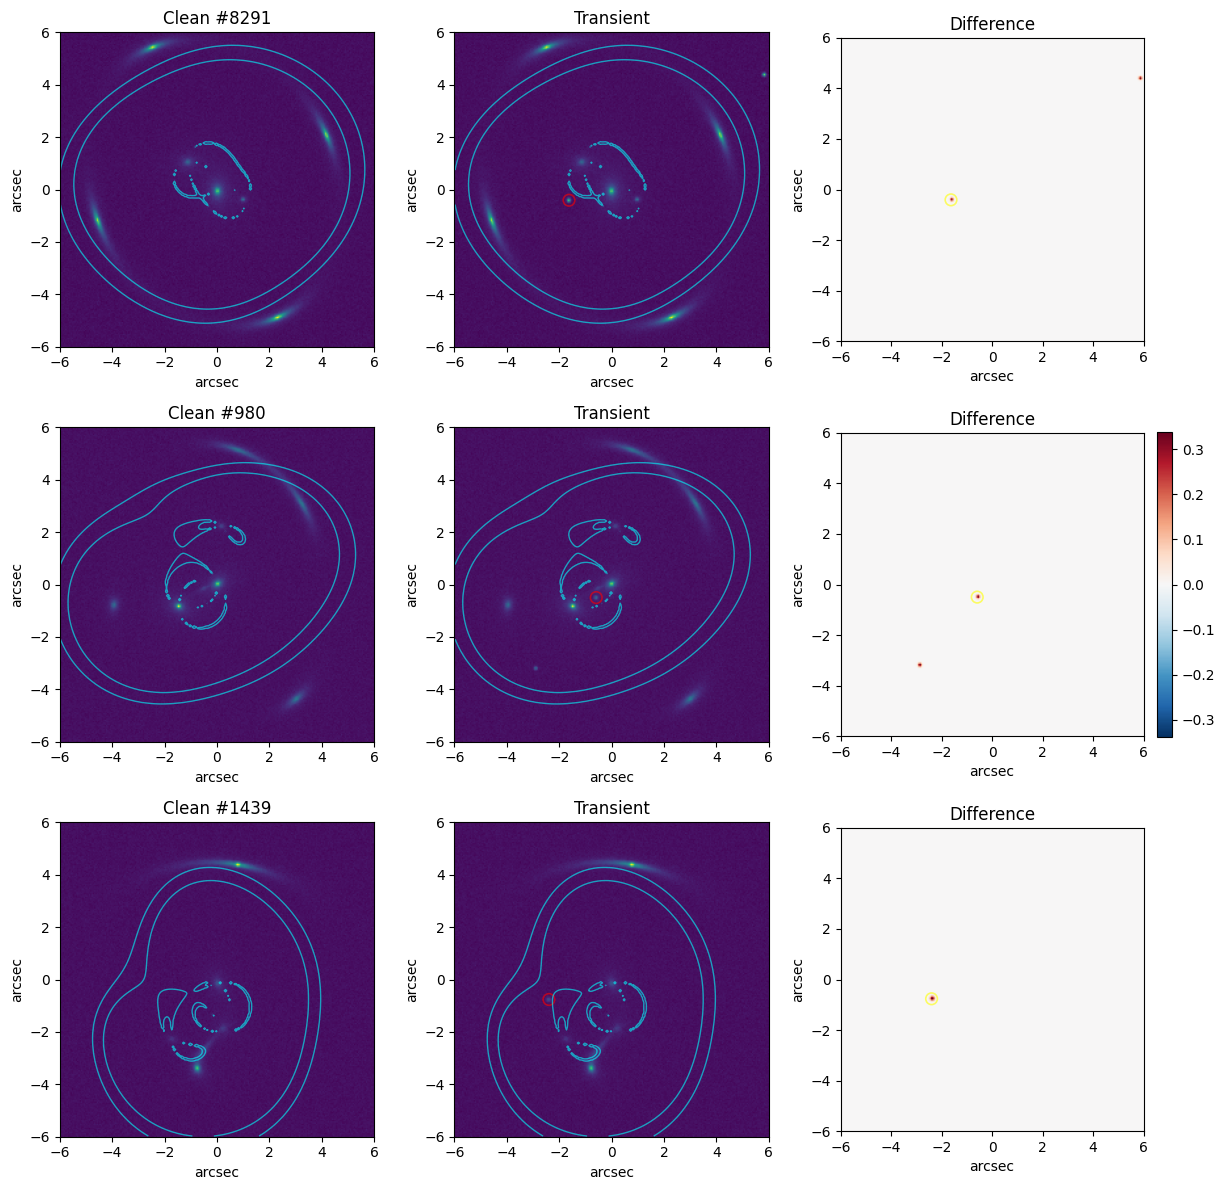

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
sample_indices = np.random.choice(len(clean_images), 3, replace=False)

pixel_scale = 0.05
img_size = clean_images[0].shape[0]
ra0 = -(img_size - 1) / 2 * pixel_scale
dec0 = -(img_size - 1) / 2 * pixel_scale
extent = [
    ra0 - pixel_scale / 2,
    ra0 + (img_size - 1) * pixel_scale + pixel_scale / 2,
    dec0 - pixel_scale / 2,
    dec0 + (img_size - 1) * pixel_scale + pixel_scale / 2,
]

# Pre-compute coordinate grids to avoid repeated allocations inside the loop.
x_coords = ra0 + np.arange(img_size) * pixel_scale
y_coords = dec0 + np.arange(img_size) * pixel_scale
xx, yy = np.meshgrid(x_coords, y_coords)

for row, idx in enumerate(sample_indices):
    meta = metadata[idx]
    lens_model = LensModel(lens_model_list=meta['lens_models'])

    mag_map = np.zeros_like(xx)
    for i in range(img_size):
        for j in range(img_size):
            try:
                mag_map[i, j] = abs(lens_model.magnification(xx[i, j], yy[i, j], meta['lens_params']))
            except Exception:
                mag_map[i, j] = 0

    clean = clean_images[idx]
    anomalous = anomalous_images[idx]
    diff = anomalous - clean
    diff_scale = np.max(np.abs(diff)) or 1.0

    axes[row, 0].imshow(clean, cmap='viridis', origin='lower', extent=extent)
    axes[row, 0].contour(xx, yy, mag_map, levels=[20], colors='cyan', linewidths=1, alpha=0.6)
    axes[row, 0].set_title(f'Clean #{idx}')

    axes[row, 1].imshow(anomalous, cmap='viridis', origin='lower', extent=extent)
    axes[row, 1].contour(xx, yy, mag_map, levels=[20], colors='cyan', linewidths=1, alpha=0.6)
    for x_img, y_img in meta.get('transient_image_positions', []):
        axes[row, 1].scatter(
            x_img,
            y_img,
            facecolors='none',
            edgecolors='red',
            linewidths=1.2,
            s=70,
            alpha=0.6,
        )
    axes[row, 1].set_title('Transient')

    im = axes[row, 2].imshow(
        diff,
        cmap='RdBu_r',
        origin='lower',
        extent=extent,
        vmin=-diff_scale,
        vmax=diff_scale,
    )
    for x_img, y_img in meta.get('transient_image_positions', []):
        axes[row, 2].scatter(
            x_img,
            y_img,
            facecolors='none',
            edgecolors='yellow',
            linewidths=1.2,
            s=70,
            alpha=0.6,
        )
    axes[row, 2].set_title('Difference')

    for col in range(3):
        axes[row, col].set_xlabel('arcsec')
        axes[row, col].set_ylabel('arcsec')

fig.tight_layout()
plt.colorbar(im, ax=axes[:, 2], fraction=0.046, pad=0.04)
plt.show()



## Summary Statistics

Print a compact set of descriptive statistics for the synthesized dataset.



In [10]:
total_pairs = len(clean_images)
print(f'Total image pairs: {total_pairs}')

if clean_images_array.size:
    print(f'Image shape: {clean_images_array.shape[1:]} pixels')


def _safe_stats(values):
    """Return mean, std, min, max for iterable values while ignoring Nones."""
    filtered = [v for v in values if v is not None]
    if not filtered:
        return None
    arr = np.array(filtered, dtype=float)
    return arr.mean(), arr.std(), arr.min(), arr.max()


z_source_stats = _safe_stats([m.get('z_source') for m in metadata])
z_lens_stats = _safe_stats([m.get('z_lens') for m in metadata])
lens_mass_stats = _safe_stats(
    mass for m in metadata for mass in m.get('lens_masses', [])
)
theta_e_stats = _safe_stats(
    lp.get('theta_E')
    for m in metadata
    for lp in m.get('lens_params', [])
)

if z_source_stats:
    mean, std, vmin, vmax = z_source_stats
    print(f'z_source: mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')
if z_lens_stats:
    mean, std, vmin, vmax = z_lens_stats
    print(f'z_lens:   mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')
if lens_mass_stats:
    mean, std, vmin, vmax = lens_mass_stats
    print(
        'lens mass (Msun): '
        f'mean={mean:.2e}, std={std:.2e}, range=[{vmin:.2e}, {vmax:.2e}]'
    )
if theta_e_stats:
    mean, std, vmin, vmax = theta_e_stats
    print(f'Einstein radius (arcsec): mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

counts = {1: 0}
for meta in metadata:
    if meta.get('num_point_sources') == 1:
        counts[1] += 1
print('Point sources per image:')
print(f"  1: {counts[1]}")



Total image pairs: 10000
Image shape: (240, 240) pixels
z_source: mean=1.999, std=0.578, range=[1.000, 3.000]
z_lens:   mean=0.409, std=0.189, range=[0.100, 1.132]
lens mass (Msun): mean=3.90e+12, std=2.49e+12, range=[1.00e+12, 1.00e+13]
Einstein radius (arcsec): mean=1.478, std=0.588, range=[0.079, 3.394]
Point sources per image:
  1: 10000


## Dataset Overview

- **Lens ensemble**: Eight singular isothermal ellipsoid halos per image: the most massive halo is placed within ±0.15″ of the stamp center, seven satellites are packed with uniform-in-area radii between 0.3–1.5×θE(main) (capped at half-FoV − 0.5″) while enforcing separations ≥max(0.25″, 1.2×pixel_scale). Halo masses still sample 10¹²–10¹³ M⊙, map to velocity dispersions through Faber–Jackson, and yield Einstein radii ≈0.1–3.3 arcsec in a Flat ΛCDM cosmology; each configuration also includes a single external shear draw γ∈[0.05, 0.12] with random position angle. Lens redshifts are drawn from a Gaussian centered at 0.4 (σ≈0.2) and clipped so every halo remains in front of its source.
- **Lens galaxy light**: Each halo carries a co-aligned Sérsic light profile. Sérsic indices scatter around 3.8 with 0.5 dispersion, half-light radii track 0.35–0.7 of the halo Einstein radius (bounded to 0.15–0.9 arcsec), and amplitudes scale with velocity dispersion (∝σ¹·²) to approximate brighter galaxies in deeper potentials.
- **Background sources**: Sources lie at redshifts 1.0–3.0 and are positioned within half of the main Einstein radius so that multiple images and arcs form. They have compact Sérsic profiles (Rₑ≈0.05–0.25 arcsec, indices 1–4) with amplitudes between 12 and 35 arbitrary counts to ensure bright lensed structures.
- **Transient injection**: Each realization adds a single source-plane point emitter placed near the caustic. Candidate seeds come from mapping μ>20 critical-curve pixels back to the source plane; the position is jittered by ≲5% of the main Einstein radius before lensing. Fluxes are 5–15% of the host source amplitude, yielding a detectable but non-dominant lensed image along the critical curve.
- **Image formation**: lenstronomy ray-traces the composite light distribution onto a 240×240 grid (0.05 arcsec/pixel). A Gaussian PSF with FWHM randomly sampled between 0.08–0.15 arcsec is applied. Gaussian detector noise and a uniform background (0.05–0.20 counts) are added once per configuration so clean and transient images share the same realization, achieving S/N≈100 on the brightest pixels.
- **Deliverables**: The notebook generates ``num_samples`` paired image cubes—`clean_images.npy` and `anomalous_images.npy`—and a metadata table (`metadata.pkl`) containing every sampled parameter (masses, redshifts, Sérsic properties, PSF widths, transient fluxes, etc.). Visualization and summary cells provide quick diagnostics of representative systems and ensemble statistics without digging into the code.

